# Step1:Load Dataset & preprocessing






In [3]:
import pandas as pd
from datasets import load_dataset

# Yelp
dataset = load_dataset('yelp_review_full')
df = dataset['train'].to_pandas()
df = df[['text', 'label']].sample(n=10000, random_state=42)
df['stars'] = df['label'] + 1

# Sentiment mapping
def rating_to_sentiment(r):
    if r >= 4:   return 'Positive'
    elif r == 3: return 'Neutral'
    else:        return 'Negative'

df['sentiment'] = df['stars'].apply(rating_to_sentiment)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

yelp_review_full/train-00000-of-00001.pa(…):   0%|          | 0.00/299M [00:00<?, ?B/s]

yelp_review_full/test-00000-of-00001.par(…):   0%|          | 0.00/23.5M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/650000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/50000 [00:00<?, ? examples/s]

In [4]:
pd.set_option('display.max_columns',None)
df.head(5)

,text,label,stars,sentiment
177288,"First of all i'm not a big fan of buffet, i tr...",0,1,Negative
238756,Thanks Yelp. I was looking for the words to de...,1,2,Negative
604225,Service was so-so. They were receiving a deliv...,2,3,Neutral
2838,Stamoolis Brothers is one of the Strip Distric...,2,3,Neutral
586957,I want to give a 2 stars because the service s...,0,1,Negative


In [5]:
df.info

<bound method DataFrame.info of                                                      text  label  stars  \
177288  First of all i'm not a big fan of buffet, i tr...      0      1   
238756  Thanks Yelp. I was looking for the words to de...      1      2   
604225  Service was so-so. They were receiving a deliv...      2      3   
2838    Stamoolis Brothers is one of the Strip Distric...      2      3   
586957  I want to give a 2 stars because the service s...      0      1   
...                                                   ...    ...    ...   
456268  Four Hours of my life I'd like to have back!\n...      0      1   
259135  Small stadium and would have great views all a...      1      2   
496284  I think Porktropolis has the BBQ thing nailed....      2      3   
512684  Best CU ever!!! Great customer service!!! Know...      4      5   
597788  Came in for late lunch on a Tuesday. I sat at ...      2      3   

       sentiment  
177288  Negative  
238756  Negative  
604225   Neutral  
2838     Neutral  
586957  Negative  
...          ...  
456268  Negative  
259135  Negative  
496284   Neutral  
512684  Positive  
597788   Neutral  

[10000 rows x 4 columns]>

In [6]:
df.describe()

,label,stars
count,10000.000000,10000.000000
mean,1.998100,2.998100
std,1.410849,1.410849
min,0.000000,1.000000
25%,1.000000,2.000000
50%,2.000000,3.000000
75%,3.000000,4.000000
max,4.000000,5.000000


In [7]:
df.columns

Index(['text', 'label', 'stars', 'sentiment'], dtype='object')

In [8]:

df.isnull().sum()

,0
text,0
label,0
stars,0
sentiment,0


In [9]:
df.duplicated().sum()

np.int64(0)

# Step 2:Text Cleaning

In [10]:
import re

def clean_text(text):
    text = str(text).lower().strip()
    text = re.sub(r'http\S+|www\.\S+', '', text)
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'[^\w\s!?.,\'"-]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['clean_text'] = df['text'].apply(clean_text)
df.to_csv('preprocessed_data.csv', index=False)

In [13]:
import re
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW

from transformers import (
    DistilBertTokenizerFast,
    DistilBertForSequenceClassification,
    get_linear_schedule_with_warmup
)

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score
)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [15]:
df = pd.read_csv('preprocessed_data.csv')

# ── Validate expected columns ─────────────────────────────────────────────────
assert 'clean_text' in df.columns, "Missing column: 'clean_text'"
assert 'sentiment'  in df.columns, "Missing column: 'sentiment'"

df = df.dropna(subset=['clean_text', 'sentiment']).reset_index(drop=True)
df['clean_text'] = df['clean_text'].astype(str)

# Define the mapping from sentiment strings to integers
sentiment_to_int_map = {'Negative': 0, 'Neutral': 1, 'Positive': 2}
# Apply the mapping to the 'sentiment' column
df['sentiment']  = df['sentiment'].map(sentiment_to_int_map).astype(int)

label_map   = {0: 'Negative', 1: 'Neutral', 2: 'Positive'}
label_names = ['Negative', 'Neutral', 'Positive']

print(f"Loaded {len(df)} rows")
print(df['sentiment'].map(label_map).value_counts())
df.head()

Loaded 10000 rows
sentiment
Negative    4025
Positive    3995
Neutral     1980
Name: count, dtype: int64


,text,label,stars,sentiment,clean_text
0,"First of all i'm not a big fan of buffet, i tr...",0,1,0,"first of all i'm not a big fan of buffet, i tr..."
1,Thanks Yelp. I was looking for the words to de...,1,2,0,thanks yelp. i was looking for the words to de...
2,Service was so-so. They were receiving a deliv...,2,3,1,service was so-so. they were receiving a deliv...
3,Stamoolis Brothers is one of the Strip Distric...,2,3,1,stamoolis brothers is one of the strip distric...
4,I want to give a 2 stars because the service s...,0,1,0,i want to give a 2 stars because the service s...


In [16]:
X = df['clean_text'].tolist()
y = df['sentiment'].tolist()

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print(f"Train : {len(X_train):,} samples")
print(f"Val   : {len(X_val):,} samples")
print(f"Test  : {len(X_test):,} samples")

Train : 7,000 samples
Val   : 1,500 samples
Test  : 1,500 samples


In [17]:
tfidf_vectorizer = TfidfVectorizer(
    max_features=50000,
    ngram_range=(1, 2),      # unigrams + bigrams
    sublinear_tf=True,       # log normalization
    min_df=2,
    strip_accents='unicode',
    analyzer='word'
)

# Fit only on train — transform all splits
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_val_tfidf   = tfidf_vectorizer.transform(X_val)
X_test_tfidf  = tfidf_vectorizer.transform(X_test)

print(f"TF-IDF feature matrix: {X_train_tfidf.shape}")

with open('tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf_vectorizer, f)
print("Saved: tfidf_vectorizer.pkl")

TF-IDF feature matrix: (7000, 50000)
Saved: tfidf_vectorizer.pkl


In [18]:
svm_model = LinearSVC(
    C=1.0,
    max_iter=2000,
    class_weight='balanced',
    random_state=42
)
svm_model.fit(X_train_tfidf, y_train)

# Validation
val_preds = svm_model.predict(X_val_tfidf)
print(f"SVM Val Accuracy : {accuracy_score(y_val, val_preds):.4f}")
print(f"SVM Val F1 (macro): {f1_score(y_val, val_preds, average='macro'):.4f}")

with open('svm_model.pkl', 'wb') as f:
    pickle.dump(svm_model, f)
print("Saved: svm_model.pkl")

SVM Val Accuracy : 0.7547
SVM Val F1 (macro): 0.6962
Saved: svm_model.pkl


SVM Test Accuracy : 0.7547
SVM Test F1 (macro): 0.6969

Classification Report:
              precision    recall  f1-score   support

    Negative       0.79      0.84      0.82       604
     Neutral       0.50      0.40      0.45       297
    Positive       0.81      0.84      0.83       599

    accuracy                           0.75      1500
   macro avg       0.70      0.70      0.70      1500
weighted avg       0.74      0.75      0.75      1500



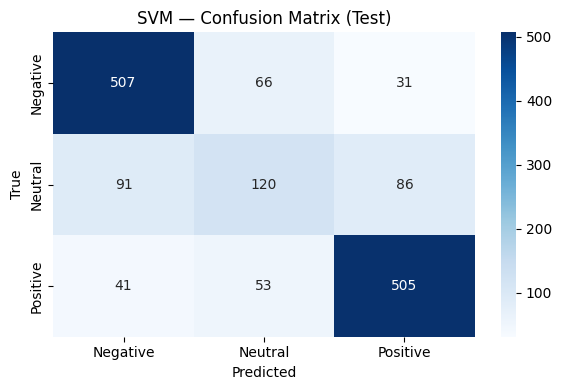

In [19]:
# Test evaluation
test_preds_svm = svm_model.predict(X_test_tfidf)
print(f"SVM Test Accuracy : {accuracy_score(y_test, test_preds_svm):.4f}")
print(f"SVM Test F1 (macro): {f1_score(y_test, test_preds_svm, average='macro'):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, test_preds_svm, target_names=label_names))

cm_svm = confusion_matrix(y_test, test_preds_svm)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_names, yticklabels=label_names)
plt.title('SVM — Confusion Matrix (Test)')
plt.ylabel('True'); plt.xlabel('Predicted')
plt.tight_layout(); plt.show()

In [20]:
MODEL_NAME = 'distilbert-base-uncased'
MAX_LEN    = 128

tokenizer = DistilBertTokenizerFast.from_pretrained(MODEL_NAME)
print("Tokenizer loaded")

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokenizer loaded


In [21]:
class ReviewDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts, self.labels = texts, labels
        self.tokenizer, self.max_len = tokenizer, max_len

    def __len__(self): return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx], max_length=self.max_len,
            truncation=True, padding='max_length', return_tensors='pt'
        )
        return {
            'input_ids'     : enc['input_ids'].squeeze(0),
            'attention_mask': enc['attention_mask'].squeeze(0),
            'label'         : torch.tensor(self.labels[idx], dtype=torch.long)
        }

BATCH_SIZE = 32

train_loader = DataLoader(ReviewDataset(X_train, y_train, tokenizer, MAX_LEN),
                          batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(ReviewDataset(X_val,   y_val,   tokenizer, MAX_LEN),
                          batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(ReviewDataset(X_test,  y_test,  tokenizer, MAX_LEN),
                          batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f"Train batches: {len(train_loader)} | Val: {len(val_loader)} | Test: {len(test_loader)}")

Train batches: 219 | Val: 47 | Test: 47


In [22]:
model = DistilBertForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=3,
    id2label={0: 'Negative', 1: 'Neutral', 2: 'Positive'},
    label2id={'Negative': 0, 'Neutral': 1, 'Positive': 2}
).to(device)
print("DistilBERT loaded")

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


DistilBERT loaded


In [23]:
def train_epoch(model, loader, optimizer, criterion, scheduler=None):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for batch in loader:
        ids  = batch['input_ids'].to(device)
        mask = batch['attention_mask'].to(device)
        lbls = batch['label'].to(device)
        optimizer.zero_grad()
        out  = model(ids, attention_mask=mask)
        loss = criterion(out.logits, lbls)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        if scheduler: scheduler.step()
        total_loss += loss.item()
        correct += (out.logits.argmax(1) == lbls).sum().item()
        total   += lbls.size(0)
    return total_loss / len(loader), correct / total


def eval_epoch(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for batch in loader:
            ids  = batch['input_ids'].to(device)
            mask = batch['attention_mask'].to(device)
            lbls = batch['label'].to(device)
            out  = model(ids, attention_mask=mask)
            loss = criterion(out.logits, lbls)
            total_loss += loss.item()
            preds = out.logits.argmax(1)
            correct += (preds == lbls).sum().item()
            total   += lbls.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(lbls.cpu().numpy())
    return total_loss / len(loader), correct / total, all_preds, all_labels

print("Training utilities defined")

Training utilities defined


In [24]:
EPOCHS = 2
LR     = 2e-5

total_steps  = len(train_loader) * EPOCHS
warmup_steps = int(total_steps * 0.1)

optimizer = AdamW(model.parameters(), lr=LR, weight_decay=0.01)
scheduler = get_linear_schedule_with_warmup(
    optimizer, num_warmup_steps=warmup_steps, num_training_steps=total_steps
)
criterion = nn.CrossEntropyLoss()

history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
best_val_acc = 0.0

print("Training DistilBERT")
print("=" * 50)

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc        = train_epoch(model, train_loader, optimizer, criterion, scheduler)
    vl_loss, vl_acc, _, _ = eval_epoch(model, val_loader, criterion)

    history['train_loss'].append(tr_loss)
    history['val_loss'].append(vl_loss)
    history['train_acc'].append(tr_acc)
    history['val_acc'].append(vl_acc)

    if vl_acc > best_val_acc:
        best_val_acc = vl_acc
        torch.save(model.state_dict(), 'best_distilbert.pt')
        print(f"  ✓ best_distilbert.pt saved (val_acc={vl_acc:.4f})")

    print(f"Epoch {epoch}/{EPOCHS} — "
          f"Train Loss: {tr_loss:.4f}  Acc: {tr_acc:.4f} | "
          f"Val Loss: {vl_loss:.4f}  Acc: {vl_acc:.4f}")

print(f"\nBest Val Accuracy: {best_val_acc:.4f}")

Training DistilBERT
  ✓ best_distilbert.pt saved (val_acc=0.7480)
Epoch 1/2 — Train Loss: 0.7426  Acc: 0.6807 | Val Loss: 0.6010  Acc: 0.7480
  ✓ best_distilbert.pt saved (val_acc=0.7700)
Epoch 2/2 — Train Loss: 0.5236  Acc: 0.7881 | Val Loss: 0.5766  Acc: 0.7700

Best Val Accuracy: 0.7700


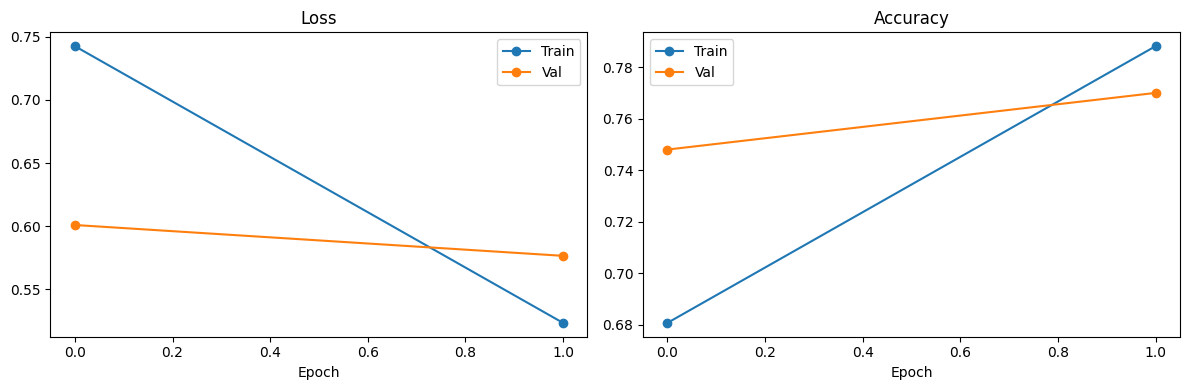

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history['train_loss'], label='Train', marker='o')
axes[0].plot(history['val_loss'],   label='Val',   marker='o')
axes[0].set_title('Loss'); axes[0].set_xlabel('Epoch'); axes[0].legend()

axes[1].plot(history['train_acc'], label='Train', marker='o')
axes[1].plot(history['val_acc'],   label='Val',   marker='o')
axes[1].set_title('Accuracy'); axes[1].set_xlabel('Epoch'); axes[1].legend()

plt.tight_layout(); plt.show()

DistilBERT Test Accuracy: 0.7627

Classification Report:
              precision    recall  f1-score   support

    Negative       0.82      0.85      0.84       604
     Neutral       0.52      0.42      0.47       297
    Positive       0.80      0.84      0.82       599

    accuracy                           0.76      1500
   macro avg       0.71      0.70      0.71      1500
weighted avg       0.75      0.76      0.76      1500



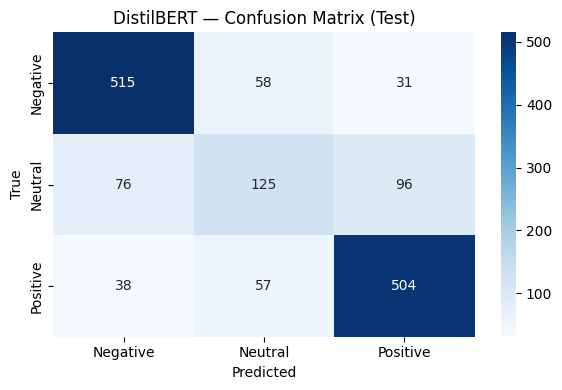

In [26]:
# Load best weights and evaluate on test set
model.load_state_dict(torch.load('best_distilbert.pt', map_location=device))

_, test_acc, test_preds, test_true = eval_epoch(model, test_loader, criterion)

print(f"DistilBERT Test Accuracy: {test_acc:.4f}")
print("\nClassification Report:")
print(classification_report(test_true, test_preds, target_names=label_names))

cm = confusion_matrix(test_true, test_preds)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_names, yticklabels=label_names)
plt.title('DistilBERT — Confusion Matrix (Test)')
plt.ylabel('True'); plt.xlabel('Predicted')
plt.tight_layout(); plt.show()

In [27]:
import os

artifacts = {
    'tfidf_vectorizer.pkl': 'TF-IDF vectorizer (50k features, unigrams+bigrams)',
    'svm_model.pkl'       : 'LinearSVC trained on TF-IDF features',
    'best_distilbert.pt'  : 'Fine-tuned DistilBERT (best val accuracy checkpoint)',
}

print("Artifact Summary")
print("=" * 65)
all_ok = True
for fname, desc in artifacts.items():
    if os.path.exists(fname):
        size = os.path.getsize(fname) / 1024
        print(f"  ✓  {fname:<28} ({size:>8,.0f} KB)  {desc}")
    else:
        print(f"  ✗  {fname:<28}  MISSING")
        all_ok = False

print()
print("All artifacts ready!" if all_ok else "Some artifacts are missing — re-run the relevant cells.")

Artifact Summary
  ✓  tfidf_vectorizer.pkl         (   1,910 KB)  TF-IDF vectorizer (50k features, unigrams+bigrams)
  ✓  svm_model.pkl                (   1,173 KB)  LinearSVC trained on TF-IDF features
  ✓  best_distilbert.pt           ( 261,588 KB)  Fine-tuned DistilBERT (best val accuracy checkpoint)

All artifacts ready!
